In [1]:
# STEP 1: Setup + load data + windowing (train-only scaling)
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
import os
print(os.listdir())

['30_univariate-Copy1.ipynb', 'zigzag_test_per_frame_bi_30_thacba.npy', 'sirikit', 'latent_test_seq_bi_30_7.npy', 'model', 'zigzag_test_per_sample_bi_30_7.npy', 'y_scaler_bivariate_30_123.save', 'knn_radius_distribution_30.png', 'bilstm_topo_aug_best_bi.pt', 'Sirikit_MULTIVARIATE-Copy1.ipynb', 'phase1-srikit.ipynb', 'sirikit_soill1_prediction.ipynb', 'Phase 2-1 day.ipynb', 'zigzag_test_per_sample_bi_30_123.npy', '30_TCN.ipynb', 'bilstm_base_best_bi.pt', '30_best_model_bivariate_123.pth', 'Sirikit_upstream_full_multivariate_daily.csv', 'latent_train_seq_bi_30_thacba.npy', 'latent_train_seq_bi_30_123.npy', '30_TCN.pdf', 'zigzag_train_per_frame_bi_30_thacba.npy', '7_Sirikit_BIVARIATE.ipynb', 'GRU-7day.ipynb', 'zigzag_test_per_frame_bi_30_123.npy', 'best_model_tcn_multiscale_30day.pth', 'GRU_best_model_srikit_7day.pth', 'Sirikit_BIVARIATE.ipynb', 'best_model_tcn_30day.pth', '7_univarite.ipynb', '30_Sirikit_BIVARIATE-7.ipynb', '30_thacba_BIVARIATE.ipynb', 'xgboost2_30day_y_pred.npy', 'zigza

In [3]:
pwd

'/home/thesis/Downloads/Thesis-20251203T130544Z-1-001/Thesis/MSEA/sirikit'

In [4]:
CSV_PATH = r"Level2_5140_1974_Sirikit.csv"
#MSEA-Res_database_v2/Dynamic_components/Level2/Level2_5140_1974_Sirikit.csv
df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").dropna(subset=["Storage_km3"]).reset_index(drop=True)
print("Data shape:", df.shape)
print(df.head())
print(df.tail())

Data shape: (13169, 2)
        Date  Storage_km3
0 1987-12-12     4.064504
1 1987-12-13     4.065823
2 1987-12-14     4.067143
3 1987-12-15     4.068463
4 1987-12-16     4.069783
            Date  Storage_km3
13164 2023-12-27     5.316066
13165 2023-12-28     5.314915
13166 2023-12-29     5.313879
13167 2023-12-30     5.312958
13168 2023-12-31     5.312153


In [5]:
# ----------------------------
# 2) Temporal split (train past, test future)
# ----------------------------
cutoff = pd.Timestamp("2016-01-01")  # same idea as before; change if you want
train_df = df[df["Date"] < cutoff].copy()
test_df  = df[df["Date"] >= cutoff].copy()
print("\nTrain:", train_df["Date"].min(), "→", train_df["Date"].max(), "n =", len(train_df))
print("Test :", test_df["Date"].min(),  "→", test_df["Date"].max(),  "n =", len(test_df))


Train: 1987-12-12 00:00:00 → 2015-12-31 00:00:00 n = 10247
Test : 2016-01-01 00:00:00 → 2023-12-31 00:00:00 n = 2922


In [6]:
# ----------------------------
# 3) Scale using TRAIN only
# ----------------------------
scaler = StandardScaler().fit(train_df[["Storage_km3"]])
train_s = scaler.transform(train_df[["Storage_km3"]]).flatten()
test_s  = scaler.transform(test_df[["Storage_km3"]]).flatten()
# ----------------------------
# 4) Make supervised windows
# ----------------------------
def make_windows(series, lookback=180, horizon=1, stride=1):
    """
    series: 1D array
    returns:
      X: [N, lookback, 1]
      y: [N] if horizon=1 else [N, horizon]
    """
    X, y = [], []
    for i in range(0, len(series) - lookback - horizon + 1, stride):
        X.append(series[i:i+lookback])
        y.append(series[i+lookback:i+lookback+horizon])
    X = np.asarray(X)[:, :, None]
    y = np.asarray(y).squeeze()
    return X, y

LOOKBACK = 180
HORIZON  = 30

X_train, y_train = make_windows(train_s, lookback=LOOKBACK, horizon=HORIZON)
X_test,  y_test  = make_windows(test_s,  lookback=LOOKBACK, horizon=HORIZON)

print("\nWindowed shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


Windowed shapes:
X_train: (10038, 180, 1) y_train: (10038, 30)
X_test : (2713, 180, 1) y_test : (2713, 30)


In [7]:
# STEP 2: BiLSTM training + latent extraction

import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ----------------------------
# 0) Reproducibility
# ----------------------------
SEED = 7

def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility for CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

print("Seed:", SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)


# ----------------------------
# 1) Convert numpy -> torch
# ----------------------------
def to_t(x):
    return torch.tensor(
        x,
        dtype=torch.float32,
        device=device
    )


train_ds = TensorDataset(
    to_t(X_train),
    to_t(y_train)
)

# Seed the DataLoader's shuffled ordering
train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_dl = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    generator=train_generator
)

test_X = to_t(X_test)
test_y = to_t(y_test)


# ----------------------------
# 2) Define BiLSTM that can return latent sequence
# ----------------------------
class BiLSTM_Inspect(nn.Module):
    def __init__(
        self,
        in_dim=1,
        hidden=128,
        layers=2,
        dropout=0.3,
        out_dim=30
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=in_dim,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        self.fc = nn.Linear(
            hidden * 2,
            out_dim
        )

    def forward(self, x, return_hidden=False):
        out, (h, c) = self.lstm(x)

        # out: [batch, lookback, 2 * hidden]
        y = self.fc(out[:, -1, :])

        if return_hidden:
            return y, out

        return y


# Must be initialized AFTER set_seed(SEED)
model = BiLSTM_Inspect(
    out_dim=HORIZON
).to(device)

print("Model initialized for seed:", SEED)

Seed: 7
Device: cpu
Model initialized for seed: 7


In [20]:
VAL_FRAC = 0.15
n_tr = len(X_train)
n_val = int(n_tr * VAL_FRAC)

# Time-based validation: final portion of training data
X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
X_val, y_val = X_train[-n_val:], y_train[-n_val:]

# Separate reproducible generator for the actual training loader
tr_generator = torch.Generator()
tr_generator.manual_seed(SEED)

tr_dl = DataLoader(
    TensorDataset(to_t(X_tr), to_t(y_tr)),
    batch_size=64,
    shuffle=True,
    generator=tr_generator
)

val_X = to_t(X_val)
val_y = to_t(y_val)

opt = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3
)

loss_fn = nn.MSELoss()

best_val = float("inf")
best_state = None

patience = 20
bad = 0

for epoch in range(400):

    # --------------------
    # Train
    # --------------------
    model.train()
    running = 0.0

    for xb, yb in tr_dl:
        opt.zero_grad(set_to_none=True)

        pred = model(xb)          # [B, HORIZON]
        loss = loss_fn(pred, yb)  # [B, HORIZON]

        loss.backward()
        opt.step()

        running += loss.item() * xb.size(0)

    train_loss = running / len(tr_dl.dataset)

    # --------------------
    # Validate
    # --------------------
    model.eval()

    with torch.no_grad():
        vpred = model(val_X)
        val_loss = loss_fn(vpred, val_y).item()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"train {train_loss:.6f} | "
            f"val {val_loss:.6f}"
        )

    # --------------------
    # Early stopping
    # --------------------
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        bad = 0

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    else:
        bad += 1

        if bad >= patience:
            print(f"Early stopping at epoch {epoch + 1}.")
            break


if best_state is None:
    raise RuntimeError("No valid best model state was recorded.")

# Restore best validation model
model.load_state_dict(
    {
        k: v.to(device)
        for k, v in best_state.items()
    }
)

print(f"Best validation loss: {best_val:.6f}")


# ----------------------------
# Forecast on test data
# ----------------------------
model.eval()

with torch.no_grad():
    y_pred_s = model(test_X).cpu().numpy()

y_true_s = test_y.cpu().numpy()


# ----------------------------
# Invert scaling
# ----------------------------
y_pred = scaler.inverse_transform(
    y_pred_s.reshape(-1, 1)
).reshape(-1, HORIZON)

y_true = scaler.inverse_transform(
    y_true_s.reshape(-1, 1)
).reshape(-1, HORIZON)


# ----------------------------
# Overall metrics
# ----------------------------
rmse = np.sqrt(
    np.mean((y_true - y_pred) ** 2)
)

mae = np.mean(
    np.abs(y_true - y_pred)
)

r2 = r2_score(
    y_true.reshape(-1),
    y_pred.reshape(-1)
)

print(
    f"\n[Test Forecast | Seed {SEED}] "
    f"RMSE={rmse:.6f} km³ | "
    f"MAE={mae:.6f} km³ | "
    f"R²={r2:.6f}"
)


# ----------------------------
# Per-horizon metrics
# ----------------------------
print("\nPer-horizon metrics:")

per_horizon_metrics = []

for h in range(HORIZON):

    rmse_h = np.sqrt(
        mean_squared_error(
            y_true[:, h],
            y_pred[:, h]
        )
    )

    mae_h = mean_absolute_error(
        y_true[:, h],
        y_pred[:, h]
    )

    r2_h = r2_score(
        y_true[:, h],
        y_pred[:, h]
    )

    per_horizon_metrics.append({
        "seed": SEED,
        "horizon_day": h + 1,
        "rmse": rmse_h,
        "mae": mae_h,
        "r2": r2_h
    })

    print(
        f"Day {h + 1:02d}: "
        f"RMSE={rmse_h:.6f} | "
        f"MAE={mae_h:.6f} | "
        f"R²={r2_h:.6f}"
    )


# ----------------------------
# Save seed-specific outputs
# ----------------------------
import os

SAVE_DIR = f"30_sirikit/seed_{SEED}"
os.makedirs(SAVE_DIR, exist_ok=True)

model_path = (
    f"{SAVE_DIR}/"
    f"best_model_sirikit_30day_seed_{SEED}.pth"
)

torch.save(
    model.state_dict(),
    model_path
)

np.save(
    f"{SAVE_DIR}/y_pred_test_seed_{SEED}.npy",
    y_pred
)

np.save(
    f"{SAVE_DIR}/y_true_test_seed_{SEED}.npy",
    y_true
)

metrics_df = pd.DataFrame(per_horizon_metrics)

metrics_df.to_csv(
    f"{SAVE_DIR}/per_horizon_metrics_seed_{SEED}.csv",
    index=False
)

overall_metrics = pd.DataFrame([{
    "seed": SEED,
    "rmse": rmse,
    "mae": mae,
    "r2": r2,
    "best_val_loss": best_val
}])

print(f"\nModel saved as: {model_path}")

Epoch  10 | train 0.084650 | val 0.065520
Epoch  20 | train 0.064480 | val 0.057663
Epoch  30 | train 0.048849 | val 0.114278
Early stopping at epoch 36.
Best validation loss: 0.049047

[Test Forecast | Seed 7] RMSE=0.349252 km³ | MAE=0.214539 km³ | R²=0.916599

Per-horizon metrics:
Day 01: RMSE=0.077115 | MAE=0.062839 | R²=0.995979
Day 02: RMSE=0.078882 | MAE=0.062363 | R²=0.995790
Day 03: RMSE=0.075025 | MAE=0.058024 | R²=0.996188
Day 04: RMSE=0.083617 | MAE=0.061303 | R²=0.995262
Day 05: RMSE=0.099650 | MAE=0.072531 | R²=0.993265
Day 06: RMSE=0.115288 | MAE=0.082625 | R²=0.990979
Day 07: RMSE=0.134732 | MAE=0.095380 | R²=0.987670
Day 08: RMSE=0.154157 | MAE=0.106318 | R²=0.983846
Day 09: RMSE=0.175619 | MAE=0.119341 | R²=0.979019
Day 10: RMSE=0.196722 | MAE=0.132792 | R²=0.973654
Day 11: RMSE=0.219965 | MAE=0.147336 | R²=0.967035
Day 12: RMSE=0.243882 | MAE=0.163799 | R²=0.959446
Day 13: RMSE=0.268317 | MAE=0.179995 | R²=0.950875
Day 14: RMSE=0.291878 | MAE=0.195387 | R²=0.941824
Da

In [14]:
import os
print(os.getcwd())

/home/thesis/Downloads/Thesis-20251203T130544Z-1-001/Thesis/MSEA/sirikit


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BiLSTM_Inspect(out_dim=30).to(device)

model_path = (
    "/home/thesis/Downloads/"
    "Thesis-20251203T130544Z-1-001/Thesis/MSEA/sirikit/"
    "30_sirikit/seed_7/best_model_sirikit_30day_seed_7.pth"
)

model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model.eval()

print("Seed 7 model loaded successfully")

# testing
xb = torch.tensor(X_test[:10], dtype=torch.float32).to(device)

with torch.no_grad():
    pred = model(xb)

print(pred.shape)

Seed 7 model loaded successfully
torch.Size([10, 30])


In [17]:
import os
with torch.no_grad():
    y_pred_s = model(test_X).cpu().numpy()

y_true_s = test_y.cpu().numpy()

y_pred = scaler.inverse_transform(
    y_pred_s.reshape(-1, 1)
).reshape(-1, 30)

y_true = scaler.inverse_transform(
    y_true_s.reshape(-1, 1)
).reshape(-1, 30)
# ----------------------------
# 5) Extract latent hidden sequence for zigzag
# ----------------------------
with torch.no_grad():
    _, latent_seq = model(test_X, return_hidden=True)

latent_seq = latent_seq.cpu().numpy()

print("Latent test sequence shape:", latent_seq.shape)

# Create seed-specific folder
os.makedirs("30_sirikit/seed_7", exist_ok=True)

# Save seed 7 outputs
np.save("30_sirikit/seed_7/30_day_latent_test_seq.npy", latent_seq)
np.save("30_sirikit/seed_7/30_day_y_true_test.npy", y_true)
np.save("30_sirikit/seed_7/30_day_y_pred_test.npy", y_pred)

print("Saved in 30_sirikit/seed_7")

Latent test sequence shape: (2713, 180, 256)
Saved in 30_sirikit/seed_7


In [12]:
# EXTRA (needed for zigzag augmentation):
# Extract latent for TRAIN windows too

# train_X_t = to_t(X_train)

# with torch.no_grad():
#     _, latent_train_seq = model(train_X_t, return_hidden=True)  # [N_train, LOOKBACK, 2H]

# latent_train_seq = latent_train_seq.cpu().numpy()
# print("Latent train sequence shape:", latent_train_seq.shape)

# np.save("sirikit/7_day_latent_train_seq.npy", latent_train_seq)
# print("Saved: latent_train_seq.npy")



In [18]:
model.eval()

train_loader = DataLoader(
    TensorDataset(to_t(X_train)),
    batch_size=128,
    shuffle=False
)

latents = []

with torch.no_grad():
    for xb in train_loader:
        xb = xb[0]
        _, latent_seq = model(xb, return_hidden=True)
        latents.append(latent_seq.cpu().numpy())

latent_train_seq = np.concatenate(latents, axis=0)

print("Latent train sequence shape:", latent_train_seq.shape)

os.makedirs("30_sirikit/seed_7", exist_ok=True)

np.save(
    "30_sirikit/seed_7/30_day_latent_train_seq.npy",
    latent_train_seq
)

print("Saved: 30_sirikit/seed_7/30_day_latent_train_seq.npy")

Latent train sequence shape: (10038, 180, 256)
Saved: 30_sirikit/seed_7/30_day_latent_train_seq.npy


In [19]:
# STEP 3: TRUE zigzag persistence features using Dionysus (TRAIN + TEST)

def rips_filtration(points, maxdim=1, maxdist=2.0):
    """
    Dionysus 2.x build: fill_rips(data, k, r) -> Filtration
    """
    pts3 = PCA(n_components=3).fit_transform(points)  # (n_points, 3)
    f = d.fill_rips(pts3, maxdim, maxdist)            # <-- returns Filtration
    f.sort()
    return f



Z_train_last: (10038, 256)
Z_test_last : (2713, 256)

=== TRAIN local zigzag ===
  computed local zigzag 10/196
  computed local zigzag 20/196
  computed local zigzag 30/196
  computed local zigzag 40/196
  computed local zigzag 50/196
  computed local zigzag 60/196
  computed local zigzag 70/196
  computed local zigzag 80/196
  computed local zigzag 90/196
  computed local zigzag 100/196
  computed local zigzag 110/196
  computed local zigzag 120/196
  computed local zigzag 130/196
  computed local zigzag 140/196
  computed local zigzag 150/196
  computed local zigzag 160/196
  computed local zigzag 170/196
  computed local zigzag 180/196
  computed local zigzag 190/196

=== TEST local zigzag ===
  computed local zigzag 10/50
  computed local zigzag 20/50
  computed local zigzag 30/50
  computed local zigzag 40/50
  computed local zigzag 50/50

Shapes:
zigzag_train_per_sample: (10038, 4)
zigzag_test_per_sample : (2713, 4)

Saved zigzag feature files.


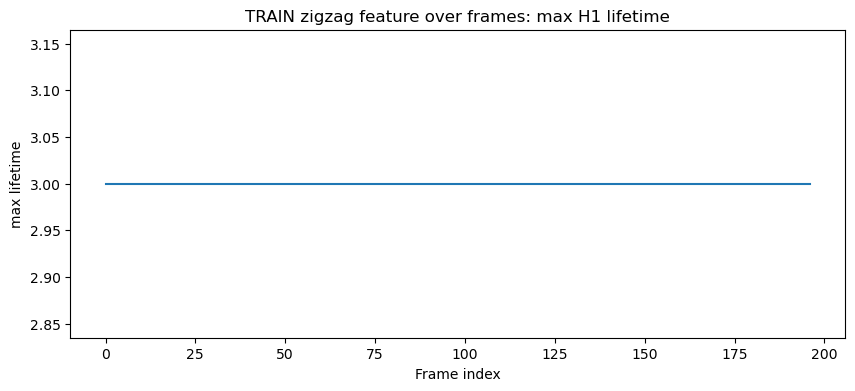

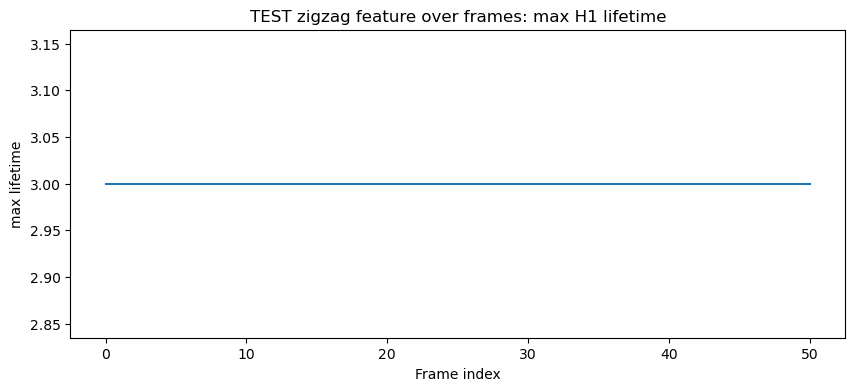

In [20]:
import numpy as np
import dionysus as d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --------------------------
# Settings (tune if slow)
# --------------------------
FRAME_SIZE = 200
STRIDE     = 50
MAXDIM     = 1
MAXDIST    = 2.0

def entropy(x):
    x = np.asarray(x, dtype=float)
    x = x[x > 0]
    if len(x) == 0:
        return 0.0
    p = x / (x.sum() + 1e-12)
    return float(-(p * np.log(p + 1e-12)).sum())

def zigzag_local_features(points_union, in_left, in_right, maxdim=1, maxdist=2.0):
    """
    True zigzag on 3 stages: Left -> Union <- Right
    using Dionysus zigzag_homology_persistence(filtration, times).

    points_union: (m, D) union points
    in_left:  boolean mask length m (True if vertex in Left frame)
    in_right: boolean mask length m (True if vertex in Right frame)

    Returns: feature vector for stage 1 (Union) based on H1 lifetimes
    """
    # Reduce to 3D for speed/stability
    pts3 = PCA(n_components=3).fit_transform(points_union)

    # Build ONE Rips filtration on union vertex set
    f = d.fill_rips(pts3, maxdim, maxdist)
    f.sort()

    # Assign simplex existence times across stages 0,1,2 (we use [birth, death) indexing)
    # Stage indices: 0=Left, 1=Union, 2=Right
    # We encode times in a 0..3 axis so that:
    # - existence in stage 0 means interval starts at 0
    # - existence through stage 1 means death >= 2
    # - existence through stage 2 means death = 3
    #
    # Rule: simplex exists in Left iff all vertices in_left
    #       simplex exists in Right iff all vertices in_right
    #       simplex always exists in Union (stage 1) because union contains all vertices

    times = []
    for s in f:
        verts = list(s)
        left_ok  = all(in_left[v]  for v in verts)
        right_ok = all(in_right[v] for v in verts)

        if left_ok and right_ok:
            times.append([0.0, 3.0])   # present in all stages
        elif left_ok and not right_ok:
            times.append([0.0, 2.0])   # stages 0 and 1
        elif (not left_ok) and right_ok:
            times.append([1.0, 3.0])   # stages 1 and 2
        else:
            times.append([1.0, 2.0])   # only stage 1

    # True zigzag persistence (supported signature in your build)
    zz, dgms, _ = d.zigzag_homology_persistence(f, times, prime=2, progress=False)

    # dgms[1] is H1 diagram
    if len(dgms) <= 1 or len(dgms[1]) == 0:
        return np.array([0, 0.0, 0.0, 0.0], dtype=float)

    H1 = dgms[1]
    pers = []
    for p in H1:
        b = getattr(p, "birth", None)
        dt = getattr(p, "death", None)
        if b is None or dt is None:
            try:
                b, dt = float(p[0]), float(p[1])
            except Exception:
                continue
        if np.isfinite(dt) and np.isfinite(b) and dt > b:
            pers.append(dt - b)

    pers = np.array(pers, dtype=float)
    if len(pers) == 0:
        return np.array([0, 0.0, 0.0, 0.0], dtype=float)

    return np.array([
        len(pers),
        pers.max(),
        pers.mean(),
        entropy(pers)
    ], dtype=float)

def zigzag_sequence_features(Z_last, frame_size=200, stride=50, maxdim=1, maxdist=2.0, max_pairs=None):
    """
    Computes local zigzag features for each adjacent frame pair.
    Then builds per-frame features by averaging adjacent pair features.
    Returns per-sample features (aligned to Z_last indices) and per-frame features.
    """
    frames_idx = [np.arange(i, i+frame_size) for i in range(0, len(Z_last) - frame_size + 1, stride)]
    n_frames = len(frames_idx)

    # Optional cap for speed debugging
    pair_count = n_frames - 1
    if max_pairs is not None:
        pair_count = min(pair_count, max_pairs)

    pair_feats = []
    for i in range(pair_count):
        idx_left = frames_idx[i]
        idx_right = frames_idx[i+1]

        # union index set (use sorted unique)
        idx_union = np.unique(np.concatenate([idx_left, idx_right]))
        pts_union = Z_last[idx_union]

        # map global indices -> local vertex ids 0..m-1
        pos = {g: j for j, g in enumerate(idx_union)}
        in_left  = np.zeros(len(idx_union), dtype=bool)
        in_right = np.zeros(len(idx_union), dtype=bool)

        for g in idx_left:
            in_left[pos[g]] = True
        for g in idx_right:
            in_right[pos[g]] = True

        feat = zigzag_local_features(pts_union, in_left, in_right, maxdim=maxdim, maxdist=maxdist)
        pair_feats.append(feat)

        if (i + 1) % 10 == 0:
            print(f"  computed local zigzag {i+1}/{pair_count}")

    pair_feats = np.array(pair_feats, dtype=float)  # (pair_count, 4)

    # Build per-frame features:
    # frame 0 uses pair 0
    # frame i uses average(pair i-1, pair i)
    # last frame uses last pair
    per_frame = []
    for i in range(n_frames):
        if i == 0:
            per_frame.append(pair_feats[0])
        elif i >= pair_count:
            per_frame.append(pair_feats[pair_count-1])
        else:
            per_frame.append(0.5 * (pair_feats[i-1] + pair_feats[i]))
    per_frame = np.array(per_frame, dtype=float)  # (n_frames, 4)

    # Map each sample to its frame index (same as before)
    sample_to_frame = np.minimum(np.arange(len(Z_last)) // stride, n_frames - 1)
    per_sample = per_frame[sample_to_frame]  # (N, 4)

    return per_sample, per_frame

# --------------------------
# Load latent sequences
# --------------------------
latent_train_seq = np.load("30_sirikit/seed_7/30_day_latent_train_seq.npy")
latent_test_seq  = np.load("30_sirikit/seed_7/30_day_latent_test_seq.npy")
Z_train_last = latent_train_seq[:, -1, :]
Z_test_last  = latent_test_seq[:, -1, :]

print("Z_train_last:", Z_train_last.shape)
print("Z_test_last :", Z_test_last.shape)

print("\n=== TRAIN local zigzag ===")
zigzag_train_per_sample, zigzag_train_per_frame = zigzag_sequence_features(
    Z_train_last, frame_size=FRAME_SIZE, stride=STRIDE, maxdim=MAXDIM, maxdist=MAXDIST
)

print("\n=== TEST local zigzag ===")
zigzag_test_per_sample, zigzag_test_per_frame = zigzag_sequence_features(
    Z_test_last, frame_size=FRAME_SIZE, stride=STRIDE, maxdim=MAXDIM, maxdist=MAXDIST
)

print("\nShapes:")
print("zigzag_train_per_sample:", zigzag_train_per_sample.shape)
print("zigzag_test_per_sample :", zigzag_test_per_sample.shape)

np.save("30_sirikit/seed_7/30_day_zigzag_train_per_sample.npy", zigzag_train_per_sample)
np.save("30_sirikit/seed_7/30_day_zigzag_test_per_sample.npy", zigzag_test_per_sample)
np.save("30_sirikit/seed_7/30_day_zigzag_train_per_frame.npy", zigzag_train_per_frame)
np.save("30_sirikit/seed_7/30_day_zigzag_test_per_frame.npy", zigzag_test_per_frame)

print("\nSaved zigzag feature files.")

# --------------------------
# Quick visualization
# --------------------------
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 1])  # max lifetime
plt.title("TRAIN zigzag feature over frames: max H1 lifetime")
plt.xlabel("Frame index")
plt.ylabel("max lifetime")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(zigzag_test_per_frame[:, 1])  # max lifetime
plt.title("TEST zigzag feature over frames: max H1 lifetime")
plt.xlabel("Frame index")
plt.ylabel("max lifetime")
plt.show()


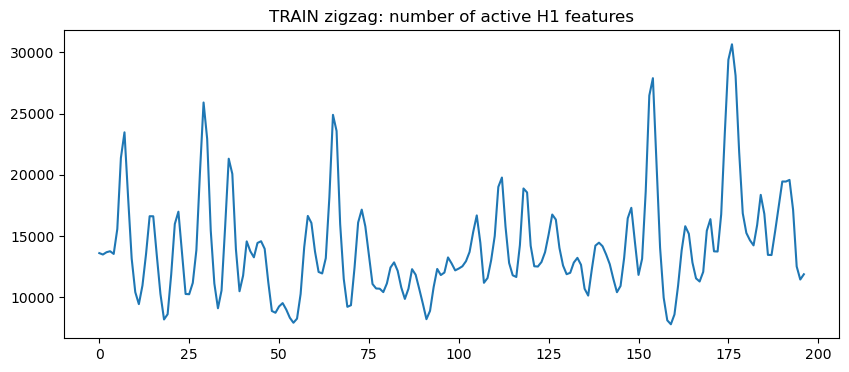

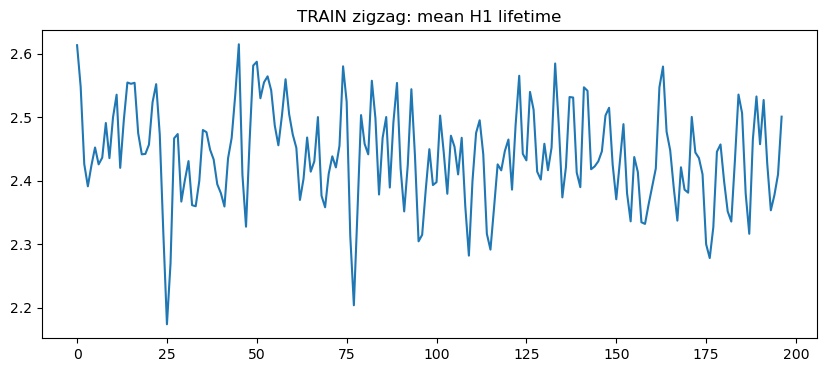

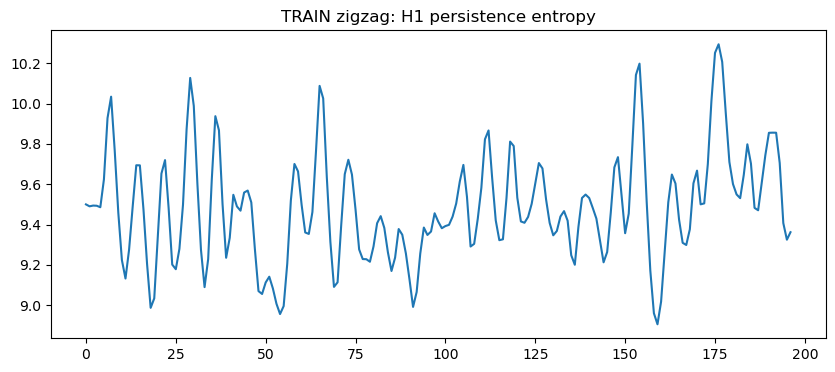

In [21]:
# 1) Number of active H1 features
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 0])
plt.title("TRAIN zigzag: number of active H1 features")
plt.show()

# 2) Mean lifetime
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 2])
plt.title("TRAIN zigzag: mean H1 lifetime")
plt.show()

# 3) Entropy (this one is key)
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 3])
plt.title("TRAIN zigzag: H1 persistence entropy")
plt.show()


In [22]:
import numpy as np

# load
phi_train = np.load("30_sirikit/seed_7/30_day_zigzag_train_per_sample.npy")
phi_test  = np.load("30_sirikit/seed_7/30_day_zigzag_test_per_sample.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("phi_train:", phi_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("phi_test:", phi_test.shape)

# hard alignment checks
assert len(X_train) == len(phi_train), "Train mismatch: X_train and phi_train lengths differ!"
assert len(X_test)  == len(phi_test),  "Test mismatch: X_test and phi_test lengths differ!"

print("Alignment OK: phi matches X by sample index")
print("phi_train stats (mean, std):")
print(phi_train.mean(axis=0), phi_train.std(axis=0))


X_train: (10038, 180, 1)
y_train: (10038, 30)
phi_train: (10038, 4)
X_test: (2713, 180, 1)
y_test: (2713, 30)
phi_test: (2713, 4)
Alignment OK: phi matches X by sample index
phi_train stats (mean, std):
[1.40452717e+04 3.00000000e+00 2.44124705e+00 9.48120770e+00] [4.15415447e+03 0.00000000e+00 7.63381594e-02 2.67669972e-01]


### Step 2 — Normalize zigzag features (train-only) + remove constant column

In [23]:
import numpy as np

phi_train = np.load("30_sirikit/seed_7/30_day_zigzag_train_per_sample.npy").astype(np.float32)
phi_test  = np.load("30_sirikit/seed_7/30_day_zigzag_test_per_sample.npy").astype(np.float32)

# 1) detect constant columns using train
std = phi_train.std(axis=0)
keep = std > 1e-8
print("std:", std)
print("keep mask:", keep)

phi_train_k = phi_train[:, keep]
phi_test_k  = phi_test[:, keep]
print("kept dims:", phi_train_k.shape[1])

# 2) normalize using train statistics only
mu = phi_train_k.mean(axis=0, keepdims=True)
sd = phi_train_k.std(axis=0, keepdims=True) + 1e-8

phi_train_n = (phi_train_k - mu) / sd
phi_test_n  = (phi_test_k  - mu) / sd

print("normalized train mean ~0:", phi_train_n.mean(axis=0))
print("normalized train std  ~1:", phi_train_n.std(axis=0))


std: [4.1541626e+03 0.0000000e+00 7.6338097e-02 2.6766694e-01]
keep mask: [ True False  True  True]
kept dims: 3
normalized train mean ~0: [3.6482461e-08 9.7286556e-07 3.0888484e-06]
normalized train std  ~1: [1.        0.9999999 1.       ]


# Step 3 — Train the topo-augmented BiLSTM (baseline + augmented)

We’ll train two models:

- Baseline BiLSTM: uses only X

- Topo-aug BiLSTM: uses X + phi_norm (3 dims)

Below is a complete, minimal PyTorch setup you can paste. It assumes:

X_train, y_train, X_test, y_test are numpy arrays like your shapes show.

phi_train_n, phi_test_n are the normalized arrays we just created.

In [24]:
# 3A) Dataset + DataLoader
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, X, y, phi=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.phi = None if phi is None else torch.tensor(phi, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.phi is None:
            return self.X[idx], self.y[idx]
        return self.X[idx], self.y[idx], self.phi[idx]

batch_size = 128

base_generator = torch.Generator()
base_generator.manual_seed(SEED)

aug_generator = torch.Generator()
aug_generator.manual_seed(SEED)

train_base = DataLoader(
    SeqDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    generator=base_generator
)

test_base = DataLoader(
    SeqDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

train_aug = DataLoader(
    SeqDataset(X_train, y_train, phi_train_n),
    batch_size=batch_size,
    shuffle=True,
    generator=aug_generator
)

test_aug = DataLoader(
    SeqDataset(X_test, y_test, phi_test_n),
    batch_size=batch_size,
    shuffle=False
)

In [25]:
import torch
import torch.nn as nn


class BiLSTMBase(nn.Module):
    def __init__(
        self,
        input_dim=1,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3,
        out_dim=30
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.head = nn.Linear(
            hidden_dim * 2,
            out_dim
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        return self.head(h_last)       # (B, 30)


class BiLSTMTopoAug(nn.Module):
    def __init__(
        self,
        input_dim=1,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3,
        topo_dim=3,
        out_dim=30
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2 + topo_dim, 128),
            nn.ReLU(),
            nn.Linear(128, out_dim)
        )

    def forward(self, x, phi):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]

        z = torch.cat(
            [h_last, phi],
            dim=1
        )

        return self.head(z)

In [26]:
import torch
import numpy as np
import torch.nn as nn

def train_one(model, loader, optimizer, device):
    model.train()
    loss_fn = nn.MSELoss()
    total = 0.0
    n = 0
    for batch in loader:
        optimizer.zero_grad()
        if len(batch) == 2:
            x, y = batch
            x, y = x.to(device), y.to(device)
            yhat = model(x)
        else:
            x, y, phi = batch
            x, y, phi = x.to(device), y.to(device), phi.to(device)
            yhat = model(x, phi)
        loss = loss_fn(yhat, y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(x)
        n += len(x)
    return total / n

@torch.no_grad()
def eval_rmse_mae(model, loader, device):
    model.eval()
    preds, trues = [], []
    for batch in loader:
        if len(batch) == 2:
            x, y = batch
            x = x.to(device)
            yhat = model(x).cpu().numpy()
        else:
            x, y, phi = batch
            x, phi = x.to(device), phi.to(device)
            yhat = model(x, phi).cpu().numpy()
        preds.append(yhat)
        trues.append(y.numpy())

    preds = np.vstack(preds)   # shape [N, 7]
    trues = np.vstack(trues)   # shape [N, 7]

    rmse = np.sqrt(np.mean((preds - trues) ** 2))
    mae  = np.mean(np.abs(preds - trues))
    return rmse, mae

@torch.no_grad()
def eval_per_day(model, loader, device):
    model.eval()
    preds, trues = [], []
    for batch in loader:
        if len(batch) == 2:
            x, y = batch
            x = x.to(device)
            yhat = model(x).cpu().numpy()
        else:
            x, y, phi = batch
            x, phi = x.to(device), phi.to(device)
            yhat = model(x, phi).cpu().numpy()
        preds.append(yhat)
        trues.append(y.numpy())

    preds = np.vstack(preds)   # [N, 7]
    trues = np.vstack(trues)   # [N, 7]

    rmses, maes = [], []
    for h in range(preds.shape[1]):
        rmse_h = np.sqrt(np.mean((preds[:, h] - trues[:, h]) ** 2))
        mae_h  = np.mean(np.abs(preds[:, h] - trues[:, h]))
        rmses.append(rmse_h)
        maes.append(mae_h)

    return np.array(rmses), np.array(maes)

In [27]:
#3D) Run baseline vs augmented

# import os, torch

# SAVE_DIR = "sirikit"
# os.makedirs(SAVE_DIR, exist_ok=True)

best_rmse_base = float("inf")
best_rmse_aug  = float("inf")
patience = 10
no_improve_base = 0
no_improve_aug  = 0



In [29]:
import os
import random
import numpy as np
import torch
from torch.utils.data import DataLoader

# ============================================================
# 1. Seed and device
# ============================================================

SEED = 7

def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)
print("Seed:", SEED)


# ============================================================
# 2. Split training data into train and validation
# ============================================================

VAL_FRAC = 0.15

n_val = int(len(X_train) * VAL_FRAC)

# Time-based split: final 15% becomes validation
X_tr_stage2 = X_train[:-n_val]
y_tr_stage2 = y_train[:-n_val]

X_val_stage2 = X_train[-n_val:]
y_val_stage2 = y_train[-n_val:]

# Topology features must use the exact same split
phi_tr_stage2 = phi_train_n[:-n_val]
phi_val_stage2 = phi_train_n[-n_val:]

print("Stage-2 training shapes:")
print("X train:", X_tr_stage2.shape)
print("y train:", y_tr_stage2.shape)
print("phi train:", phi_tr_stage2.shape)

print("\nStage-2 validation shapes:")
print("X val:", X_val_stage2.shape)
print("y val:", y_val_stage2.shape)
print("phi val:", phi_val_stage2.shape)

print("\nTest shapes:")
print("X test:", X_test.shape)
print("y test:", y_test.shape)
print("phi test:", phi_test_n.shape)


# ============================================================
# 3. Create DataLoaders
# ============================================================

batch_size = 128

# Separate generators with the same seed
base_generator = torch.Generator()
base_generator.manual_seed(SEED)

aug_generator = torch.Generator()
aug_generator.manual_seed(SEED)


# ----------------------------
# Baseline loaders
# ----------------------------

train_base = DataLoader(
    SeqDataset(
        X_tr_stage2,
        y_tr_stage2
    ),
    batch_size=batch_size,
    shuffle=True,
    generator=base_generator
)

val_base = DataLoader(
    SeqDataset(
        X_val_stage2,
        y_val_stage2
    ),
    batch_size=batch_size,
    shuffle=False
)

test_base = DataLoader(
    SeqDataset(
        X_test,
        y_test
    ),
    batch_size=batch_size,
    shuffle=False
)


# ----------------------------
# Topology-augmented loaders
# ----------------------------

train_aug = DataLoader(
    SeqDataset(
        X_tr_stage2,
        y_tr_stage2,
        phi_tr_stage2
    ),
    batch_size=batch_size,
    shuffle=True,
    generator=aug_generator
)

val_aug = DataLoader(
    SeqDataset(
        X_val_stage2,
        y_val_stage2,
        phi_val_stage2
    ),
    batch_size=batch_size,
    shuffle=False
)

test_aug = DataLoader(
    SeqDataset(
        X_test,
        y_test,
        phi_test_n
    ),
    batch_size=batch_size,
    shuffle=False
)


# ============================================================
# 4. Initialize fresh Stage-B models
# ============================================================

# Reset before baseline initialization
set_seed(SEED)

base = BiLSTMBase(
    input_dim=1,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3,
    out_dim=30
).to(device)


# Reset before augmented initialization
set_seed(SEED)

aug = BiLSTMTopoAug(
    input_dim=1,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3,
    topo_dim=phi_train_n.shape[1],
    out_dim=30
).to(device)


# ============================================================
# 5. Optimizers
# ============================================================

opt_base = torch.optim.Adam(
    base.parameters(),
    lr=1e-3
)

opt_aug = torch.optim.Adam(
    aug.parameters(),
    lr=1e-3
)

print("\nModels and optimizers initialized.")


# ============================================================
# 6. Checkpoint and early-stopping setup
# ============================================================

SAVE_DIR = "30_sirikit/seed_7"
os.makedirs(SAVE_DIR, exist_ok=True)

BASE_PATH = (
    f"{SAVE_DIR}/30_day_bilstm_base_best_sirikit.pt"
)

AUG_PATH = (
    f"{SAVE_DIR}/30_day_bilstm_topo_aug_best_sirikit.pt"
)

best_rmse_base = float("inf")
best_rmse_aug = float("inf")

patience = 10

no_improve_base = 0
no_improve_aug = 0

max_epochs = 200


# ============================================================
# 7. Train using validation RMSE for checkpoint selection
# ============================================================

for ep in range(1, max_epochs + 1):

    # Train one epoch
    loss_base = train_one(
        base,
        train_base,
        opt_base,
        device
    )

    loss_aug = train_one(
        aug,
        train_aug,
        opt_aug,
        device
    )

    # Evaluate on VALIDATION, not test
    val_rmse_base, val_mae_base = eval_rmse_mae(
        base,
        val_base,
        device
    )

    val_rmse_aug, val_mae_aug = eval_rmse_mae(
        aug,
        val_aug,
        device
    )

    print(
        f"Epoch {ep:03d} | "
        f"Base loss={loss_base:.6f} "
        f"val RMSE={val_rmse_base:.6f} "
        f"val MAE={val_mae_base:.6f} | "
        f"Aug loss={loss_aug:.6f} "
        f"val RMSE={val_rmse_aug:.6f} "
        f"val MAE={val_mae_aug:.6f}"
    )

    # --------------------------------------------------------
    # Baseline checkpoint
    # --------------------------------------------------------

    if val_rmse_base < best_rmse_base - 1e-6:

        best_rmse_base = val_rmse_base
        no_improve_base = 0

        torch.save(
            {
                "model_state": base.state_dict(),
                "optimizer_state": opt_base.state_dict(),
                "val_rmse": val_rmse_base,
                "val_mae": val_mae_base,
                "seed": SEED,
                "config": {
                    "model": "BiLSTMBase",
                    "input_dim": 1,
                    "out_dim": 30,
                    "hidden_dim": 128,
                    "num_layers": 2,
                    "dropout": 0.3,
                    "lookback": X_train.shape[1]
                }
            },
            BASE_PATH
        )

        print("Saved best baseline checkpoint.")

    else:
        no_improve_base += 1


    # --------------------------------------------------------
    # Topology-augmented checkpoint
    # --------------------------------------------------------

    if val_rmse_aug < best_rmse_aug - 1e-6:

        best_rmse_aug = val_rmse_aug
        no_improve_aug = 0

        torch.save(
            {
                "model_state": aug.state_dict(),
                "optimizer_state": opt_aug.state_dict(),
                "val_rmse": val_rmse_aug,
                "val_mae": val_mae_aug,
                "seed": SEED,
                "config": {
                    "model": "BiLSTMTopoAug",
                    "input_dim": 1,
                    "out_dim": 30,
                    "hidden_dim": 128,
                    "num_layers": 2,
                    "dropout": 0.3,
                    "topo_dim": phi_train_n.shape[1],
                    "lookback": X_train.shape[1]
                },
                "zigzag_norm": {
                    "mu": mu,
                    "sd": sd,
                    "keep_mask": keep
                }
            },
            AUG_PATH
        )

        print("Saved best topology-augmented checkpoint.")

    else:
        no_improve_aug += 1


    # Stop only when both models have stopped improving
    if (
        no_improve_base >= patience
        and no_improve_aug >= patience
    ):
        print(
            f"\nEarly stopping at epoch {ep}. "
            f"Neither model improved for {patience} epochs."
        )
        break


print("\nBest validation RMSE baseline:", best_rmse_base)
print("Best validation RMSE topology-augmented:", best_rmse_aug)


# ============================================================
# 8. Load best validation checkpoints
# ============================================================

base_checkpoint = torch.load(
    BASE_PATH,
    map_location=device,
    weights_only=False
)

aug_checkpoint = torch.load(
    AUG_PATH,
    map_location=device,
    weights_only=False
)

base.load_state_dict(
    base_checkpoint["model_state"]
)

aug.load_state_dict(
    aug_checkpoint["model_state"]
)

base.eval()
aug.eval()

print("\nBest validation checkpoints loaded.")


# ============================================================
# 9. Final test evaluation — only once
# ============================================================

test_rmse_base, test_mae_base = eval_rmse_mae(
    base,
    test_base,
    device
)

test_rmse_aug, test_mae_aug = eval_rmse_mae(
    aug,
    test_aug,
    device
)

print("\n================ FINAL TEST RESULTS ================")

print(
    f"Baseline | "
    f"RMSE={test_rmse_base:.6f} | "
    f"MAE={test_mae_base:.6f}"
)

print(
    f"Topo-Aug | "
    f"RMSE={test_rmse_aug:.6f} | "
    f"MAE={test_mae_aug:.6f}"
)

improvement = (
    (test_rmse_base - test_rmse_aug)
    / test_rmse_base
) * 100

print(
    f"RMSE improvement from topology: "
    f"{improvement:.2f}%"
)


# ============================================================
# 10. Final test metrics for each forecast day
# ============================================================

base_day_rmse, base_day_mae = eval_per_day(
    base,
    test_base,
    device
)

aug_day_rmse, aug_day_mae = eval_per_day(
    aug,
    test_aug,
    device
)

print("\nPer-day test metrics:")

for h in range(30):
    print(
        f"Day {h + 1:02d} | "
        f"Base RMSE={base_day_rmse[h]:.6f}, "
        f"Base MAE={base_day_mae[h]:.6f} | "
        f"Aug RMSE={aug_day_rmse[h]:.6f}, "
        f"Aug MAE={aug_day_mae[h]:.6f}"
    )

Using device: cpu
Seed: 7
Stage-2 training shapes:
X train: (8533, 180, 1)
y train: (8533, 30)
phi train: (8533, 3)

Stage-2 validation shapes:
X val: (1505, 180, 1)
y val: (1505, 30)
phi val: (1505, 3)

Test shapes:
X test: (2713, 180, 1)
y test: (2713, 30)
phi test: (2713, 3)

Models and optimizers initialized.
Epoch 001 | Base loss=0.315329 val RMSE=0.298659 val MAE=0.186714 | Aug loss=0.336610 val RMSE=0.304290 val MAE=0.199023
Saved best baseline checkpoint.
Saved best topology-augmented checkpoint.
Epoch 002 | Base loss=0.119430 val RMSE=0.258820 val MAE=0.155161 | Aug loss=0.123112 val RMSE=0.267011 val MAE=0.165325
Saved best baseline checkpoint.
Saved best topology-augmented checkpoint.
Epoch 003 | Base loss=0.107934 val RMSE=0.269266 val MAE=0.163073 | Aug loss=0.104869 val RMSE=0.255087 val MAE=0.162701
Saved best topology-augmented checkpoint.
Epoch 004 | Base loss=0.099669 val RMSE=0.253714 val MAE=0.154096 | Aug loss=0.094829 val RMSE=0.243733 val MAE=0.152979
Saved best 

In [31]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------
# Load baseline checkpoint
# ----------------------------
ckpt_b = torch.load(
    "30_sirikit/seed_7/30_day_bilstm_base_best_sirikit.pt",
    map_location=device,
    weights_only=False
)

base_best = BiLSTMBase(
    input_dim=ckpt_b["config"]["input_dim"],
    hidden_dim=ckpt_b["config"]["hidden_dim"],
    num_layers=ckpt_b["config"]["num_layers"],
    dropout=ckpt_b["config"]["dropout"],
    out_dim=ckpt_b["config"]["out_dim"]
).to(device)

base_best.load_state_dict(ckpt_b["model_state"])
base_best.eval()


# ----------------------------
# Load topology checkpoint
# ----------------------------
ckpt_a = torch.load(
    "30_sirikit/seed_7/30_day_bilstm_topo_aug_best_sirikit.pt",
    map_location=device,
    weights_only=False
)

aug_best = BiLSTMTopoAug(
    input_dim=ckpt_a["config"]["input_dim"],
    hidden_dim=ckpt_a["config"]["hidden_dim"],
    num_layers=ckpt_a["config"]["num_layers"],
    dropout=ckpt_a["config"]["dropout"],
    topo_dim=ckpt_a["config"]["topo_dim"],
    out_dim=ckpt_a["config"]["out_dim"]
).to(device)

aug_best.load_state_dict(ckpt_a["model_state"])
aug_best.eval()

print("Best baseline and topology models loaded.")

Best baseline and topology models loaded.


In [32]:
# ----------------------------
# Final test evaluation
# ----------------------------
test_rmse_base, test_mae_base = eval_rmse_mae(
    base_best,
    test_base,
    device
)

test_rmse_aug, test_mae_aug = eval_rmse_mae(
    aug_best,
    test_aug,
    device
)

print("\n===== SEED 7 TEST RESULTS =====")
print(
    f"Baseline | RMSE: {test_rmse_base:.6f} | "
    f"MAE: {test_mae_base:.6f}"
)

print(
    f"Topo-Aug | RMSE: {test_rmse_aug:.6f} | "
    f"MAE: {test_mae_aug:.6f}"
)

improvement = (
    (test_rmse_base - test_rmse_aug)
    / test_rmse_base
) * 100

print(f"Topology RMSE improvement: {improvement:.2f}%")


===== SEED 7 TEST RESULTS =====
Baseline | RMSE: 0.301654 | MAE: 0.187984
Topo-Aug | RMSE: 0.282953 | MAE: 0.180784
Topology RMSE improvement: 6.20%


In [33]:
base_day_rmse, base_day_mae = eval_per_day(
    base_best,
    test_base,
    device
)

aug_day_rmse, aug_day_mae = eval_per_day(
    aug_best,
    test_aug,
    device
)

print("\nPer-day test metrics:")

for h in range(30):
    print(
        f"Day {h + 1:02d} | "
        f"Base RMSE={base_day_rmse[h]:.6f}, "
        f"MAE={base_day_mae[h]:.6f} | "
        f"Topo RMSE={aug_day_rmse[h]:.6f}, "
        f"MAE={aug_day_mae[h]:.6f}"
    )


Per-day test metrics:
Day 01 | Base RMSE=0.069537, MAE=0.054459 | Topo RMSE=0.071191, MAE=0.052349
Day 02 | Base RMSE=0.061827, MAE=0.046978 | Topo RMSE=0.058277, MAE=0.042151
Day 03 | Base RMSE=0.069740, MAE=0.053849 | Topo RMSE=0.061083, MAE=0.045774
Day 04 | Base RMSE=0.069832, MAE=0.054594 | Topo RMSE=0.063315, MAE=0.046660
Day 05 | Base RMSE=0.082686, MAE=0.062322 | Topo RMSE=0.076438, MAE=0.057136
Day 06 | Base RMSE=0.092918, MAE=0.069189 | Topo RMSE=0.087490, MAE=0.063535
Day 07 | Base RMSE=0.112310, MAE=0.080164 | Topo RMSE=0.104394, MAE=0.074990
Day 08 | Base RMSE=0.130698, MAE=0.092476 | Topo RMSE=0.120463, MAE=0.085538
Day 09 | Base RMSE=0.150056, MAE=0.104211 | Topo RMSE=0.139472, MAE=0.099736
Day 10 | Base RMSE=0.174632, MAE=0.121042 | Topo RMSE=0.159716, MAE=0.113609
Day 11 | Base RMSE=0.191787, MAE=0.133404 | Topo RMSE=0.178512, MAE=0.127215
Day 12 | Base RMSE=0.206610, MAE=0.142965 | Topo RMSE=0.198679, MAE=0.142956
Day 13 | Base RMSE=0.227782, MAE=0.157689 | Topo RMSE

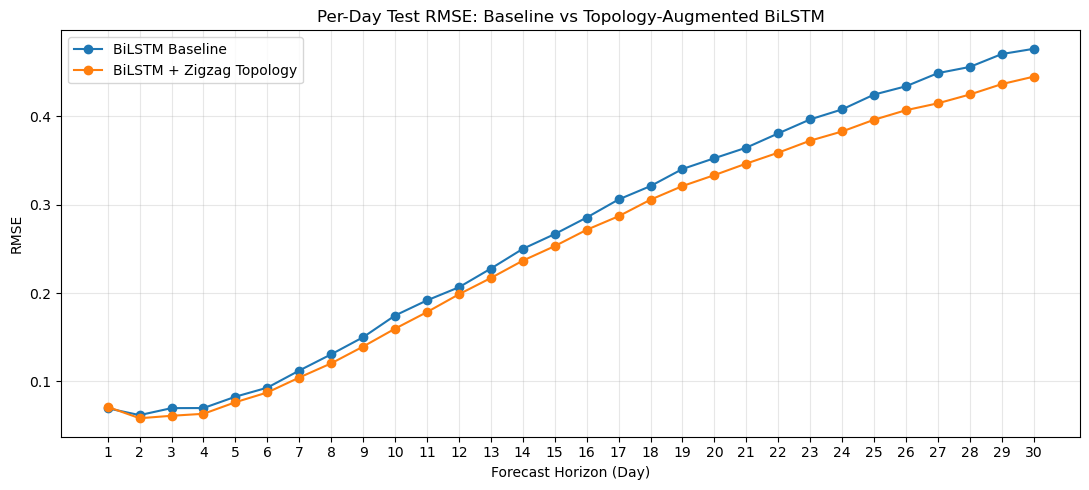

In [34]:
import numpy as np
import matplotlib.pyplot as plt

days = np.arange(1, 31)

# RMSE plot
plt.figure(figsize=(11, 5))

plt.plot(
    days,
    base_day_rmse,
    marker="o",
    label="BiLSTM Baseline"
)

plt.plot(
    days,
    aug_day_rmse,
    marker="o",
    label="BiLSTM + Zigzag Topology"
)

plt.xlabel("Forecast Horizon (Day)")
plt.ylabel("RMSE")
plt.title("Per-Day Test RMSE: Baseline vs Topology-Augmented BiLSTM")
plt.xticks(days)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "30_sirikit/seed_7/seed_7_per_day_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# load the models for vizualization 

In [35]:
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- load baseline checkpoint ----
ckpt_b = torch.load(
    "30_sirikit/seed_7/30_day_bilstm_base_best_sirikit.pt",
    map_location=device,
    weights_only=False
)

base_best = BiLSTMBase(
    input_dim=ckpt_b["config"]["input_dim"],
    hidden_dim=ckpt_b["config"]["hidden_dim"],
    num_layers=ckpt_b["config"]["num_layers"],
    dropout=ckpt_b["config"]["dropout"],
    out_dim=ckpt_b["config"]["out_dim"]
).to(device)

base_best.load_state_dict(ckpt_b["model_state"])
base_best.eval()


# ---- load topo-aug checkpoint ----
ckpt_a = torch.load(
    "30_sirikit/seed_7/30_day_bilstm_topo_aug_best_sirikit.pt",
    map_location=device,
    weights_only=False
)

aug_best = BiLSTMTopoAug(
    input_dim=ckpt_a["config"]["input_dim"],
    hidden_dim=ckpt_a["config"]["hidden_dim"],
    num_layers=ckpt_a["config"]["num_layers"],
    dropout=ckpt_a["config"]["dropout"],
    topo_dim=ckpt_a["config"]["topo_dim"],
    out_dim=ckpt_a["config"]["out_dim"]
).to(device)

aug_best.load_state_dict(ckpt_a["model_state"])
aug_best.eval()


# ---- restore zigzag normalization from checkpoint ----
mu = ckpt_a["zigzag_norm"]["mu"]
sd = ckpt_a["zigzag_norm"]["sd"]
keep = ckpt_a["zigzag_norm"]["keep_mask"]

print("Loaded best seed 7 models.")
print("Baseline best validation RMSE:", ckpt_b["val_rmse"])
print("Topo-aug best validation RMSE:", ckpt_a["val_rmse"])
print("Topo keep mask:", keep)

Loaded best seed 7 models.
Baseline best validation RMSE: 0.23175971
Topo-aug best validation RMSE: 0.23302236
Topo keep mask: [ True False  True  True]


## Recreate phi_test_n exactly like training (from checkpoint

In [36]:
import numpy as np

phi_test_raw = np.load("30_sirikit/seed_7/30_day_zigzag_test_per_sample.npy").astype(np.float32)

# keep only non-constant columns (same mask as training)
phi_test_k = phi_test_raw[:, keep]

# normalize using train stats saved in checkpoint
phi_test_n = (phi_test_k - mu) / (sd + 1e-8)

print("phi_test_n shape:", phi_test_n.shape)
print("phi_test_n mean/std (rough):", phi_test_n.mean(axis=0), phi_test_n.std(axis=0))


phi_test_n shape: (2713, 3)
phi_test_n mean/std (rough): [ 0.11847171 -0.07126804  0.19831103] [0.7148849  0.91871375 0.7487106 ]


In [23]:
## Helper functions (latent extraction + prediction)

In [37]:
import torch
import numpy as np

@torch.no_grad()
def extract_h_last_from_lstm(model, X_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    outs = []

    for i in range(0, len(X), batch_size):
        xb = X[i:i + batch_size].to(device)
        out, _ = model.lstm(xb)       # (B, T, 2H)
        h_last = out[:, -1, :]        # (B, 2H)
        outs.append(h_last.cpu().numpy())

    return np.vstack(outs)            # (N, 2H)


@torch.no_grad()
def predict_base(model, X_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    preds = []

    for i in range(0, len(X), batch_size):
        xb = X[i:i + batch_size].to(device)
        yhat = model(xb).cpu().numpy()  # (B, 30)
        preds.append(yhat)

    return np.vstack(preds)             # (N, 30)


@torch.no_grad()
def predict_aug(model, X_np, phi_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    P = torch.tensor(phi_np, dtype=torch.float32)
    preds = []

    for i in range(0, len(X), batch_size):
        xb = X[i:i + batch_size].to(device)
        pb = P[i:i + batch_size].to(device)

        yhat = model(xb, pb).cpu().numpy()  # (B, 30)
        preds.append(yhat)

    return np.vstack(preds)                  # (N, 30)

## Extract latents + do PCA→3D + compute errors

In [38]:
from sklearn.decomposition import PCA
import numpy as np

# 1) Extract last hidden state
Zb_te = extract_h_last_from_lstm(base_best, X_test, device)
Za_te = extract_h_last_from_lstm(aug_best, X_test, device)

print("Zb_te:", Zb_te.shape, "Za_te:", Za_te.shape)

# 2) Fit PCA on combined test latents
Z_all = np.vstack([Zb_te, Za_te])

pca = PCA(
    n_components=3,
    random_state=SEED
).fit(Z_all)

Zb_te3 = pca.transform(Zb_te)
Za_te3 = pca.transform(Za_te)

# 3) Predictions and per-sample absolute errors
pred_b = predict_base(base_best, X_test, device)             # (N, 30)
pred_a = predict_aug(aug_best, X_test, phi_test_n, device)   # (N, 30)

err_b = np.mean(np.abs(pred_b - y_test), axis=1)
err_a = np.mean(np.abs(pred_a - y_test), axis=1)

print("Pred shapes:", pred_b.shape, pred_a.shape)
print("Error shapes:", err_b.shape, err_a.shape)
print("Error mean baseline vs aug:", err_b.mean(), err_a.mean())

Zb_te: (2713, 256) Za_te: (2713, 256)
Pred shapes: (2713, 30) (2713, 30)
Error shapes: (2713,) (2713,)
Error mean baseline vs aug: 0.18798417691106956 0.18078387694176346


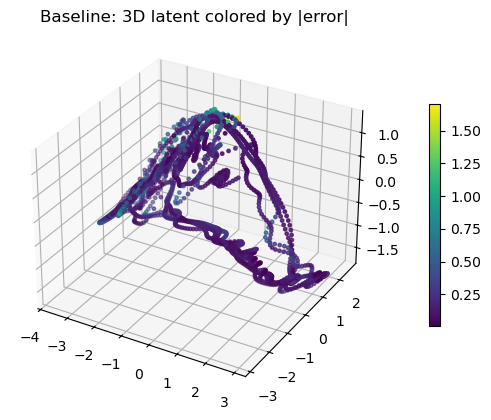

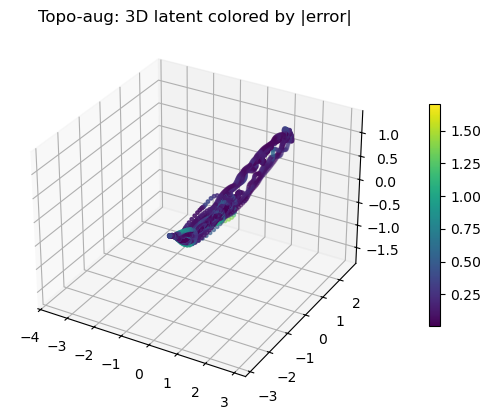

In [39]:
## 3D scatter plots (colored by error)

import numpy as np
import matplotlib.pyplot as plt

def plot_3d_same_axes(Z3, values, title, lims, vmin=None, vmax=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], s=6, c=values, vmin=vmin, vmax=vmax)
    plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
    ax.set_title(title)

    ax.set_xlim(lims[0]); ax.set_ylim(lims[1]); ax.set_zlim(lims[2])
    plt.show()

# shared limits across both
lims = (
    (min(Zb_te3[:,0].min(), Za_te3[:,0].min()), max(Zb_te3[:,0].max(), Za_te3[:,0].max())),
    (min(Zb_te3[:,1].min(), Za_te3[:,1].min()), max(Zb_te3[:,1].max(), Za_te3[:,1].max())),
    (min(Zb_te3[:,2].min(), Za_te3[:,2].min()), max(Zb_te3[:,2].max(), Za_te3[:,2].max())),
)

# shared color scale too
vmin = min(err_b.min(), err_a.min())
vmax = max(err_b.max(), err_a.max())

plot_3d_same_axes(Zb_te3, err_b, "Baseline: 3D latent colored by |error|", lims, vmin, vmax)
plot_3d_same_axes(Za_te3, err_a, "Topo-aug: 3D latent colored by |error|", lims, vmin, vmax)

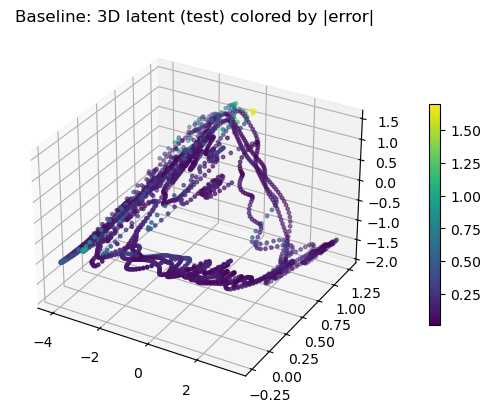

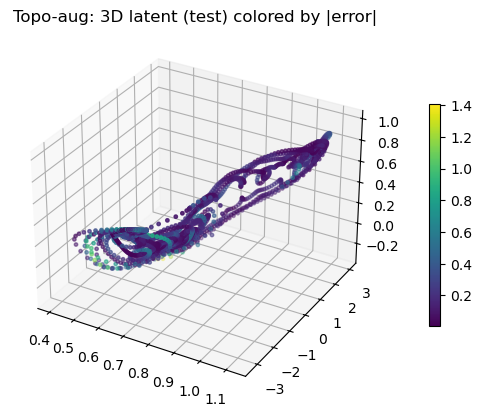

In [40]:
import matplotlib.pyplot as plt

def plot_3d(Z3, values, title):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], s=6, c=values)
    plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
    ax.set_title(title)
    plt.show()

plot_3d(Zb_te3, err_b, "Baseline: 3D latent (test) colored by |error|")
plot_3d(Za_te3, err_a, "Topo-aug: 3D latent (test) colored by |error|")


# Where along this latent curve does topology change?

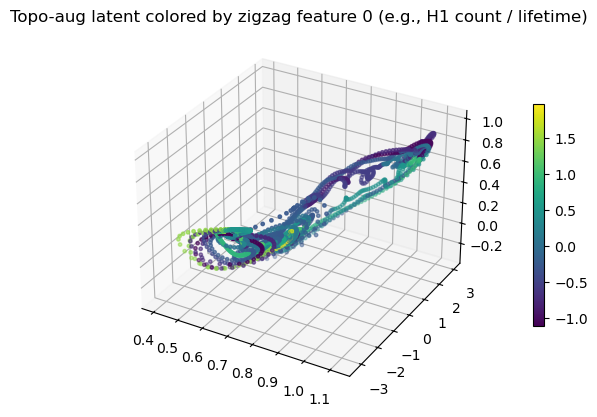

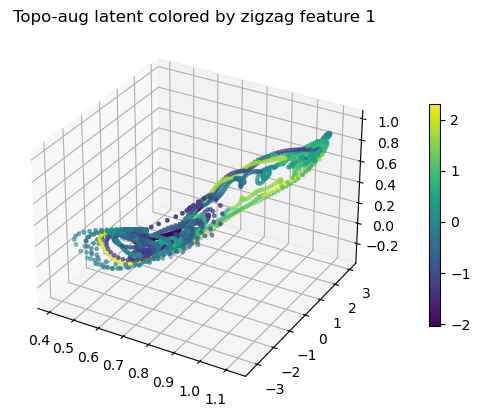

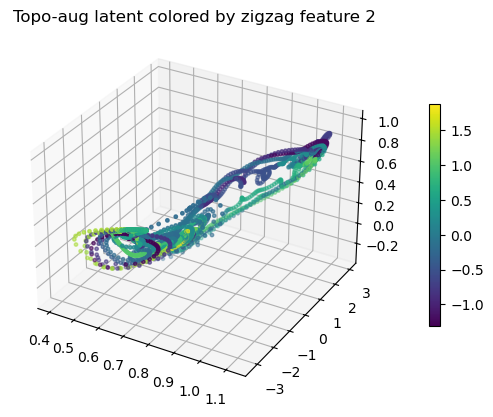

In [41]:
plot_3d(Za_te3, phi_test_n[:,0],
        "Topo-aug latent colored by zigzag feature 0 (e.g., H1 count / lifetime)")

plot_3d(Za_te3, phi_test_n[:,1],
        "Topo-aug latent colored by zigzag feature 1")

plot_3d(Za_te3, phi_test_n[:,2],
        "Topo-aug latent colored by zigzag feature 2")


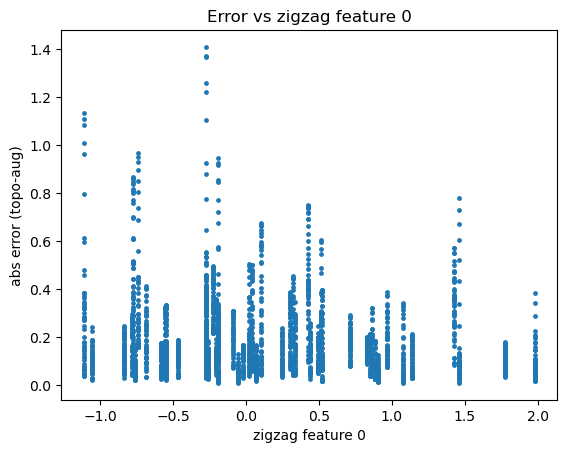

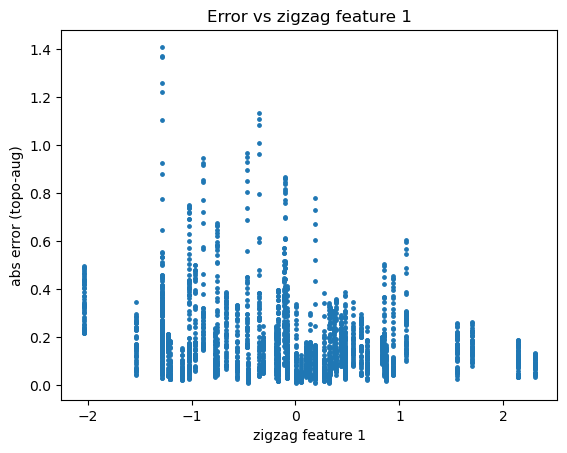

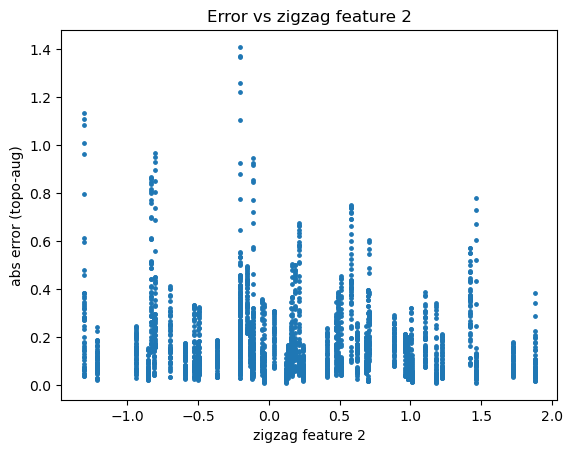

In [42]:
import matplotlib.pyplot as plt

for i in range(phi_test_n.shape[1]):
    plt.figure()
    plt.scatter(phi_test_n[:, i], err_a, s=6)
    plt.xlabel(f"zigzag feature {i}")
    plt.ylabel("abs error (topo-aug)")
    
    plt.title(f"Error vs zigzag feature {i}")
    plt.show()


# Zoom into a specific zigzag regime and visualize the actual zigzag construction

## Identify “interesting” indices

In [43]:
# choose zigzag feature that looks strongest (start with feature 2)
zz = phi_test_n[:, 2]

# get indices of top and bottom 1%
hi_idx = np.argsort(zz)[-int(0.01 * len(zz)):]
lo_idx = np.argsort(zz)[:int(0.01 * len(zz)):]

print("High zigzag indices:", hi_idx[:5])
print("Low zigzag indices:", lo_idx[:5])


High zigzag indices: [1571 1570 1569 1568 1567]
Low zigzag indices: [2197 2169 2168 2167 2166]


In [35]:
## For ONE index, extract zigzag point clouds

In [36]:
# idx = hi_idx[0]   # try a high-zigzag region first

# # retrieve the original latent window you used for zigzag
# # (this depends on how you stored windows — adapt variable names)
# latent_window = latent_windows_test[idx]   # shape (T, latent_dim)

# # PCA to 3D (same projection used earlier)
# latent_3d = pca.transform(latent_window)

# # split into left / right (as used in zigzag construction)
# T = latent_3d.shape[0]
# mid = T // 2
# left = latent_3d[:mid]
# right = latent_3d[mid:]


In [35]:
import numpy as np

np.save("30_sirikit/30_day_cache_Zb_te.npy", Zb_te)
np.save("30_sirikit/30_day_cache_Za_te.npy", Za_te)
np.save("30_sirikit/30_day_cache_Zb_te3.npy", Zb_te3)
np.save("30_sirikit/30_day_cache_Za_te3.npy", Za_te3)
np.save("30_sirikit/30_day_cache_pred_b.npy", pred_b)
np.save("30_sirikit/30_day_cache_pred_a.npy", pred_a)
np.save("30_sirikit/30_day_cache_err_b.npy", err_b)
np.save("30_sirikit/30_day_cache_err_a.npy", err_a)
np.save("30_sirikit/30_day_cache_phi_test_n.npy", phi_test_n)
np.save("30_sirikit/30_day_cache_hi_idx.npy", hi_idx)
np.save("30_sirikit/30_day_cache_lo_idx.npy", lo_idx)

print("Cached arrays saved")


Cached arrays saved


In [36]:
import os

os.listdir("30_sirikit")


['30_day_cache_err_a.npy',
 '30_day_cache_hi_idx.npy',
 '30_day_zigzag_test_per_frame.npy',
 '30_day_zigzag_train_per_frame.npy',
 '30_day_cache_Za_te3.npy',
 '30_day_cache_lo_idx.npy',
 '30_day_cache_err_b.npy',
 '30_day_zigzag_train_per_sample.npy',
 '30_day_cache_Zb_te3.npy',
 '30_day_y_true_test.npy',
 '30_day_bilstm_topo_aug_best_sirikit.pt',
 '30_day_zigzag_test_per_sample.npy',
 '30_day_bilstm_base_best_sirikit.pt',
 '30_day_cache_phi_test_n.npy',
 '30_day_cache_pred_b.npy',
 '30_day_cache_Zb_te.npy',
 '30_day_cache_pred_a.npy',
 '30_day_latent_test_seq.npy',
 '30_day_y_pred_test.npy',
 '30_day_cache_Za_te.npy']

In [44]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error

def eval_full_base(model, loader, device):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)   # [B,180,1]
            yb = yb.to(device)   # [B,7]

            out = model(xb)      # [B,7]

            ys.append(yb.detach().cpu().numpy())
            preds.append(out.detach().cpu().numpy())

    y_true = np.concatenate(ys).ravel()
    y_pred = np.concatenate(preds).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae, y_true, y_pred

def eval_full_aug(model, loader, device):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for batch in loader:
            xb  = batch[0].to(device)   # [B,180,1]
            yb  = batch[1].to(device)   # [B,7]
            phi = batch[2].to(device)   # [B,k]

            out = model(xb, phi)        # [B,7]

            ys.append(yb.detach().cpu().numpy())
            preds.append(out.detach().cpu().numpy())

    y_true = np.concatenate(ys).ravel()
    y_pred = np.concatenate(preds).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae, y_true, y_pred

rmse_b, mae_b, y_true_b, y_pred_b = eval_full_base(base_best, test_base, device)
rmse_a, mae_a, y_true_a, y_pred_a = eval_full_aug(aug_best, test_aug, device)

print(rmse_b, mae_b, y_true_b.shape, y_pred_b.shape)
print(rmse_a, mae_a, y_true_a.shape, y_pred_a.shape)

print("max |True - Baseline| :", np.max(np.abs(y_true_b - y_pred_b)))
print("max |True - Topo|     :", np.max(np.abs(y_true_b - y_pred_a)))
print("max |Baseline - Topo| :", np.max(np.abs(y_pred_b - y_pred_a)))

0.30165426706065235 0.1879841834306717 (81390,) (81390,)
0.2829534284887172 0.18078388273715973 (81390,) (81390,)
max |True - Baseline| : 2.7518218
max |True - Topo|     : 2.214755
max |Baseline - Topo| : 1.073459


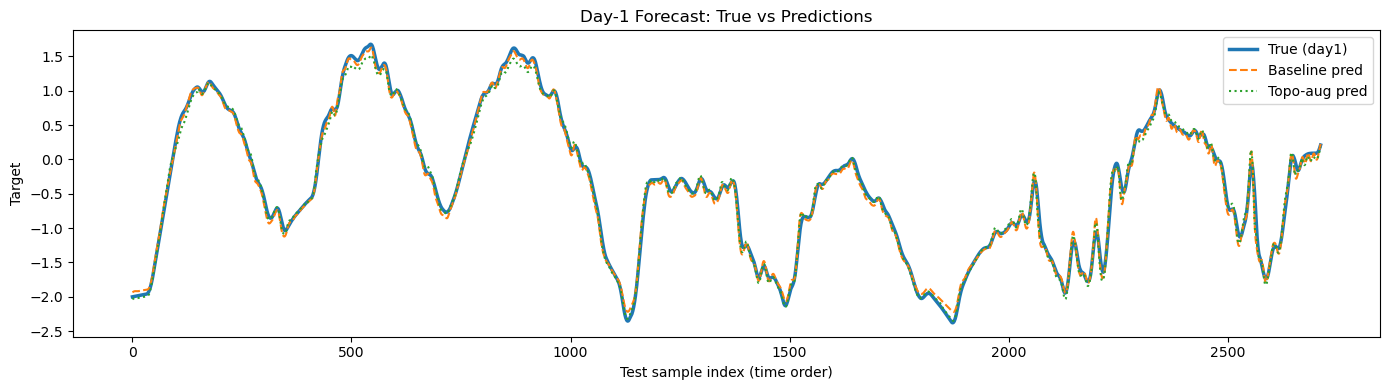

In [45]:
plt.figure(figsize=(14,4))

plt.plot(y_test[:,0], label="True (day1)", linewidth=2.5)
plt.plot(pred_b[:,0], label="Baseline pred", linestyle="--")
plt.plot(pred_a[:,0], label="Topo-aug pred", linestyle=":")

plt.title("Day-1 Forecast: True vs Predictions")
plt.xlabel("Test sample index (time order)")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.show()

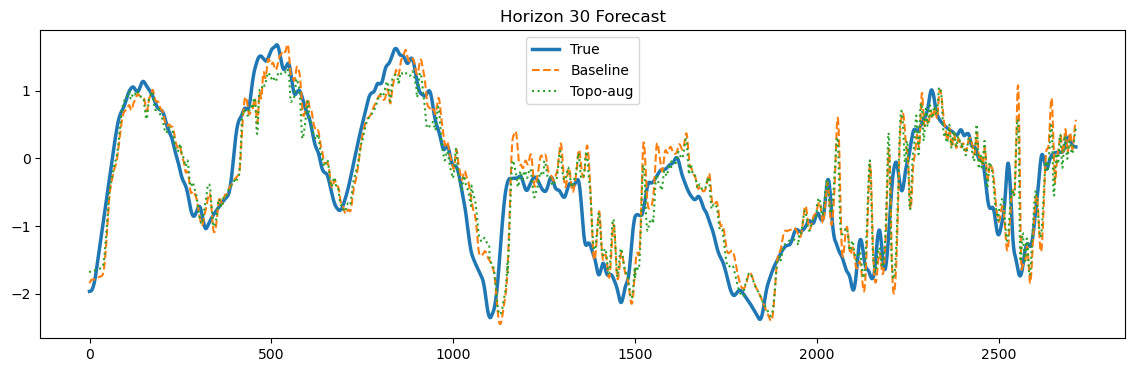

In [46]:
h = 29   # choose horizon

plt.figure(figsize=(14,4))
plt.plot(y_test[:,h], label="True", linewidth=2.5)
plt.plot(pred_b[:,h], label="Baseline", linestyle="--")
plt.plot(pred_a[:,h], label="Topo-aug", linestyle=":")
plt.title(f"Horizon {h+1} Forecast")
plt.legend()
plt.show()

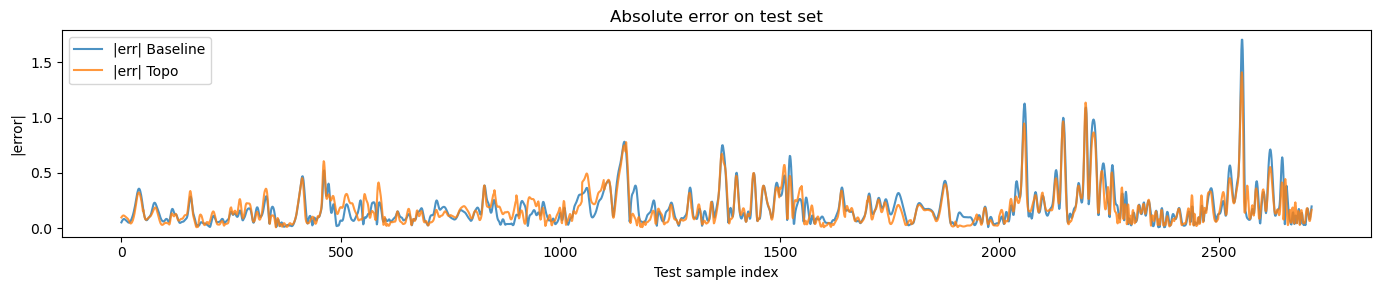

In [47]:
plt.figure(figsize=(14,3))
plt.plot(np.abs(err_b), label="|err| Baseline", alpha=0.8)
plt.plot(np.abs(err_a), label="|err| Topo", alpha=0.8)
plt.title("Absolute error on test set")
plt.xlabel("Test sample index")
plt.ylabel("|error|")
plt.legend()
plt.tight_layout()
plt.show()

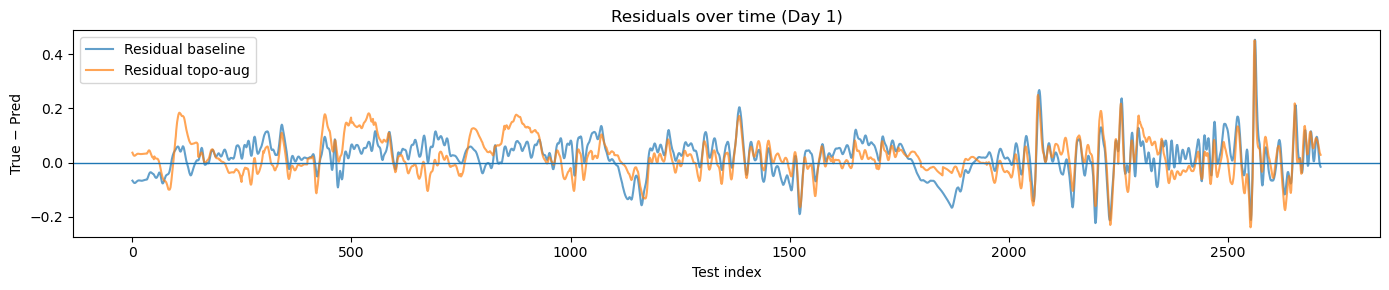

Residual step std (baseline): 0.012505579911638262
Residual step std (topo):     0.012604183306820149


In [48]:
err_b = y_test[:,0] - pred_b[:,0]
err_a = y_test[:,0] - pred_a[:,0]

plt.figure(figsize=(14,3))
plt.plot(err_b, label="Residual baseline", alpha=0.7)
plt.plot(err_a, label="Residual topo-aug", alpha=0.7)
plt.axhline(0, linewidth=1)

plt.title("Residuals over time (Day 1)")
plt.xlabel("Test index")
plt.ylabel("True − Pred")

plt.legend()
plt.tight_layout()
plt.show()

dres_b = np.diff(err_b)
dres_a = np.diff(err_a)

print("Residual step std (baseline):", dres_b.std())
print("Residual step std (topo):    ", dres_a.std())

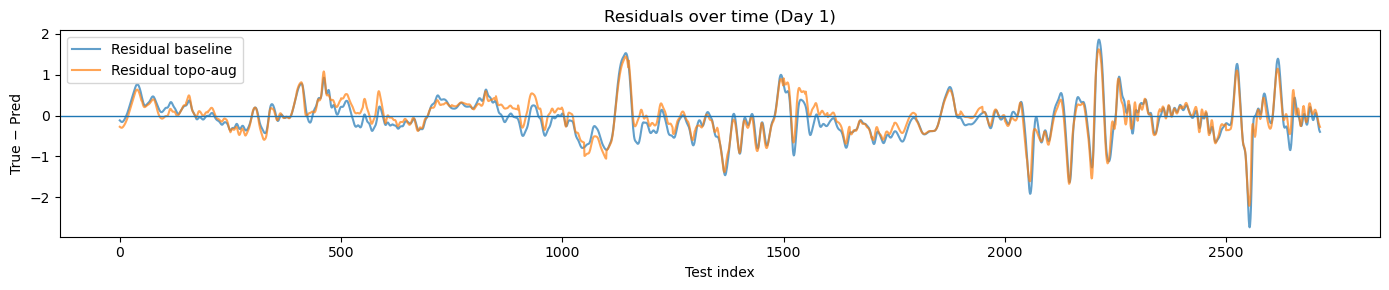

Residual step std (baseline): 0.05897146366371714
Residual step std (topo):     0.06050148323073915


In [49]:
h = 29

err_b = y_test[:,h] - pred_b[:,h]
err_a = y_test[:,h] - pred_a[:,h]

plt.figure(figsize=(14,3))
plt.plot(err_b, label="Residual baseline", alpha=0.7)
plt.plot(err_a, label="Residual topo-aug", alpha=0.7)
plt.axhline(0, linewidth=1)

plt.title("Residuals over time (Day 1)")
plt.xlabel("Test index")
plt.ylabel("True − Pred")

plt.legend()
plt.tight_layout()
plt.show()

dres_b = np.diff(err_b)
dres_a = np.diff(err_a)

print("Residual step std (baseline):", dres_b.std())
print("Residual step std (topo):    ", dres_a.std())

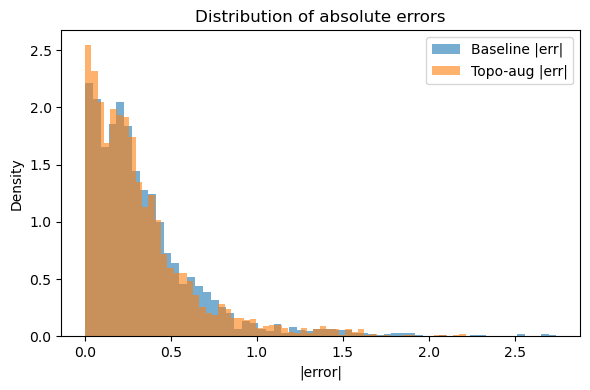

50 pct |err| baseline: 0.25429395176381275 | topo: 0.24311811514475767
75 pct |err| baseline: 0.4454544757446528 | topo: 0.4218123142945155
90 pct |err| baseline: 0.7119623344913395 | topo: 0.6915056186743784
95 pct |err| baseline: 0.9603800956025486 | topo: 0.9442229522880273
99 pct |err| baseline: 1.620313272529804 | topo: 1.498373033481089
100 pct |err| baseline: 2.742225862947973 | topo: 2.214755027894075


In [50]:
abs_b = np.abs(err_b)
abs_a = np.abs(err_a)

plt.figure(figsize=(6,4))
plt.hist(abs_b, bins=60, alpha=0.6, label="Baseline |err|", density=True)
plt.hist(abs_a, bins=60, alpha=0.6, label="Topo-aug |err|", density=True)
plt.title("Distribution of absolute errors")
plt.xlabel("|error|")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

for q in [50, 75, 90, 95, 99, 100]:
    print(q, "pct |err| baseline:", np.percentile(abs_b, q),
          "| topo:", np.percentile(abs_a, q))

In [51]:
from sklearn.decomposition import PCA
import numpy as np

# Zb_te: (N, D) baseline latents
# Za_te: (N, D) topo-aug latents

Z_all = np.vstack([Zb_te, Za_te])

pca = PCA(n_components=3, random_state=0)
pca.fit(Z_all)

Zb_te3 = pca.transform(Zb_te)
Za_te3 = pca.transform(Za_te)

In [52]:
d_b = np.linalg.norm(Zb_te[1:] - Zb_te[:-1], axis=1)
d_a = np.linalg.norm(Za_te[1:] - Za_te[:-1], axis=1)

print("Baseline step variance:", d_b.std())
print("Topo-aug step variance:", d_a.std())

Baseline step variance: 0.08831079
Topo-aug step variance: 0.05298963


In [53]:
print("Baseline mean step:", d_b.mean(), "std:", d_b.std())
print("Topo-aug mean step:", d_a.mean(), "std:", d_a.std())

Baseline mean step: 0.09836197 std: 0.08831079
Topo-aug mean step: 0.066240214 std: 0.05298963


In [54]:
import numpy as np

def perm_test_var_ratio(a, b, n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    obs = np.var(a) / np.var(b)
    pooled = np.concatenate([a, b])
    n = len(a)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        a_p = pooled[:n]
        b_p = pooled[n:]
        stat = np.var(a_p) / np.var(b_p)
        if stat >= obs:
            count += 1
    return obs, (count + 1) / (n_perm + 1)

obs, p = perm_test_var_ratio(d_b, d_a)
print("Var ratio (baseline/topo):", obs, "p-value:", p)

Var ratio (baseline/topo): 2.7774472 p-value: 0.0001999600079984003


kNN radius mean baseline: 0.17113879825442704
kNN radius mean topo:     0.11875125138626126


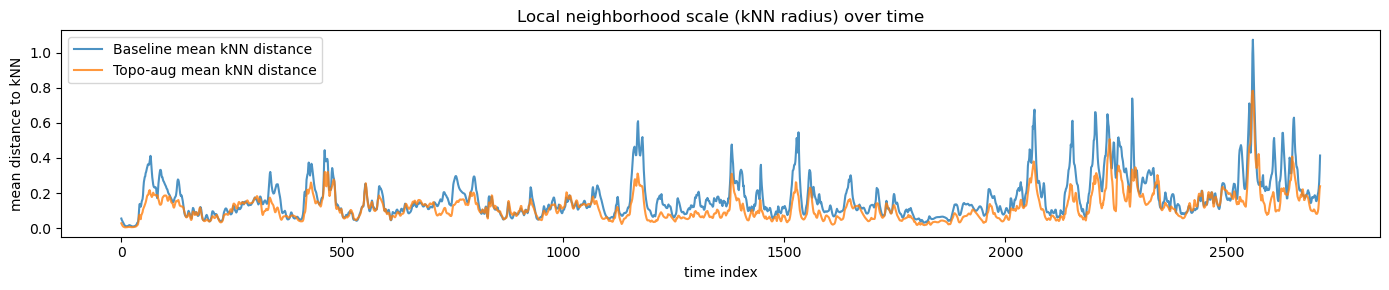

kNN radius std baseline: 0.11766715535182397
kNN radius std topo:     0.07881114036978185


In [55]:
from sklearn.neighbors import NearestNeighbors
import numpy as np, matplotlib.pyplot as plt

def knn_radius(Z, k=10):
    nn = NearestNeighbors(n_neighbors=k+1).fit(Z)
    dists, _ = nn.kneighbors(Z)        # first neighbor is itself
    return dists[:, 1:].mean(axis=1)   # mean distance to k nearest neighbors

r_b = knn_radius(Zb_te, k=10)
r_a = knn_radius(Za_te, k=10)

print("kNN radius mean baseline:", r_b.mean())
print("kNN radius mean topo:    ", r_a.mean())

#topo model → slightly tighter + more stable geometry if less val

plt.figure(figsize=(14,3))
plt.plot(r_b, label="Baseline mean kNN distance", alpha=0.8)
plt.plot(r_a, label="Topo-aug mean kNN distance", alpha=0.8)
plt.title("Local neighborhood scale (kNN radius) over time")
plt.xlabel("time index")
plt.ylabel("mean distance to kNN")
plt.legend()
plt.tight_layout()
plt.show()

print("kNN radius std baseline:", r_b.std())
print("kNN radius std topo:    ", r_a.std())

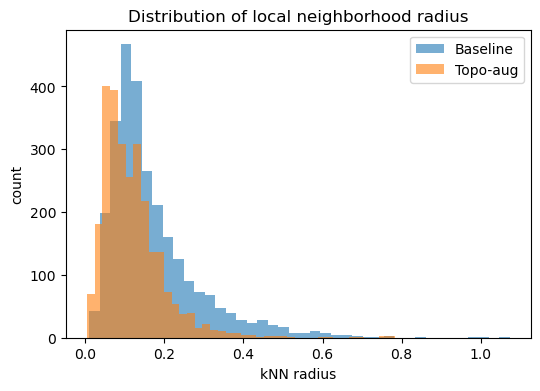

In [56]:
plt.figure(figsize=(6,4))
plt.hist(r_b, bins=40, alpha=0.6, label="Baseline")
plt.hist(r_a, bins=40, alpha=0.6, label="Topo-aug")
plt.xlabel("kNN radius")
plt.ylabel("count")
plt.legend()
plt.title("Distribution of local neighborhood radius")
plt.show()

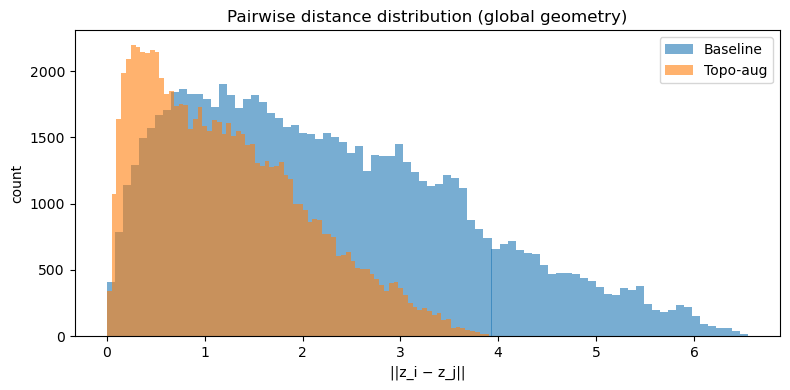

In [53]:
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng(0)
idx = rng.choice(len(Zb_te), size=min(2000, len(Zb_te)), replace=False)

def pairwise_sample(Z, idx, m=200000):
    # sample random pairs
    pairs = rng.integers(0, len(idx), size=(m,2))
    A = Z[idx[pairs[:,0]]]
    B = Z[idx[pairs[:,1]]]
    return np.linalg.norm(A-B, axis=1)

pd_b = pairwise_sample(Zb_te, idx, m=80000)
pd_a = pairwise_sample(Za_te, idx, m=80000)

plt.figure(figsize=(8,4))
plt.hist(pd_b, bins=80, alpha=0.6, label="Baseline")
plt.hist(pd_a, bins=80, alpha=0.6, label="Topo-aug")
plt.title("Pairwise distance distribution (global geometry)")
plt.xlabel("||z_i − z_j||")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
import numpy as np
from scipy.stats import f

n_b = len(r_b)
n_a = len(r_a)

var_b = np.var(r_b, ddof=1)
var_a = np.var(r_a, ddof=1)

if var_b > var_a:
    F = var_b / var_a
    df1 = n_b - 1
    df2 = n_a - 1
else:
    F = var_a / var_b
    df1 = n_a - 1
    df2 = n_b - 1

p_value = 2 * (1 - f.cdf(F, df1, df2))

print("Variance baseline:", var_b)
print("Variance topo:", var_a)
print("F statistic:", F)
print("p-value:", p_value)

Variance baseline: 0.001884762788944868
Variance topo: 0.0008405659807767856
F statistic: 2.2422544238622617
p-value: 2.220446049250313e-16


In [55]:
print("Variance ratio (baseline/topo):", var_b / var_a)

Variance ratio (baseline/topo): 2.2422544238622617


In [56]:
from scipy.stats import pearsonr, spearmanr
err_b_aligned = err_b[1:]
err_a_aligned = err_a[1:]
# Baseline
r_pb, p_pb = pearsonr(d_b, err_b_aligned)
r_sb, p_sb = spearmanr(d_b, err_b_aligned)

# Topo
r_pa, p_pa = pearsonr(d_a, err_a_aligned)
r_sa, p_sa = spearmanr(d_a, err_a_aligned)

print("Baseline Pearson r:", r_pb, "p:", p_pb)
print("Baseline Spearman r:", r_sb, "p:", p_sb)
print()
print("Topo Pearson r:", r_pa, "p:", p_pa)
print("Topo Spearman r:", r_sa, "p:", p_sa)

Baseline Pearson r: -0.006157806753618252 p: 0.7485631964367891
Baseline Spearman r: 0.09014550200599773 p: 2.577438587955758e-06

Topo Pearson r: -0.0905765878013743 p: 2.3070046257620834e-06
Topo Spearman r: -0.0048985592266051975 p: 0.7987342687553912


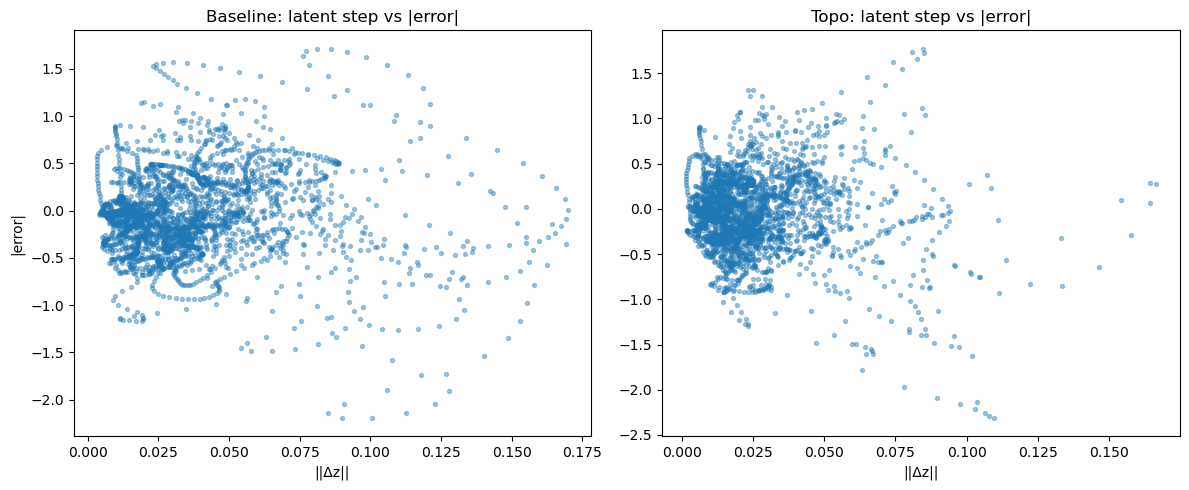

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(d_b, err_b_aligned, s=8, alpha=0.4)
plt.title("Baseline: latent step vs |error|")
plt.xlabel("||Δz||")
plt.ylabel("|error|")

plt.subplot(1,2,2)
plt.scatter(d_a, err_a_aligned, s=8, alpha=0.4)
plt.title("Topo: latent step vs |error|")
plt.xlabel("||Δz||")

plt.tight_layout()
plt.show()

In [58]:
threshold_b = np.percentile(err_b_aligned, 95)
threshold_a = np.percentile(err_a_aligned, 95)

spike_idx_b = err_b_aligned >= threshold_b
spike_idx_a = err_a_aligned >= threshold_a

print("Baseline mean step size during spikes:",
      d_b[spike_idx_b].mean())

print("Baseline mean step size normal:",
      d_b[~spike_idx_b].mean())

print()
print("Topo mean step size during spikes:",
      d_a[spike_idx_a].mean())

print("Topo mean step size normal:",
      d_a[~spike_idx_a].mean())

Baseline mean step size during spikes: 0.048863992
Baseline mean step size normal: 0.037623554

Topo mean step size during spikes: 0.038531322
Topo mean step size normal: 0.025545552


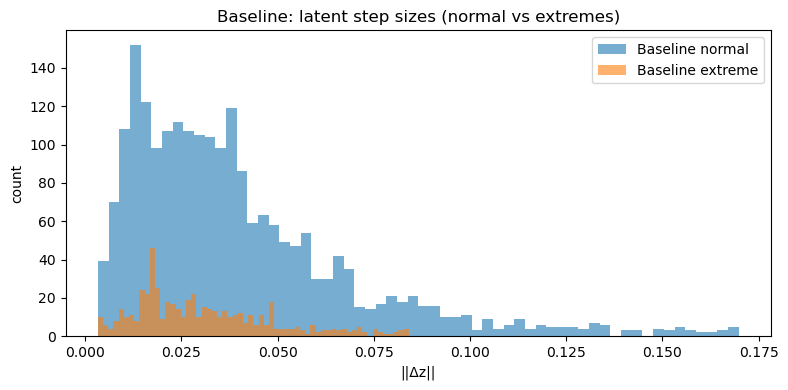

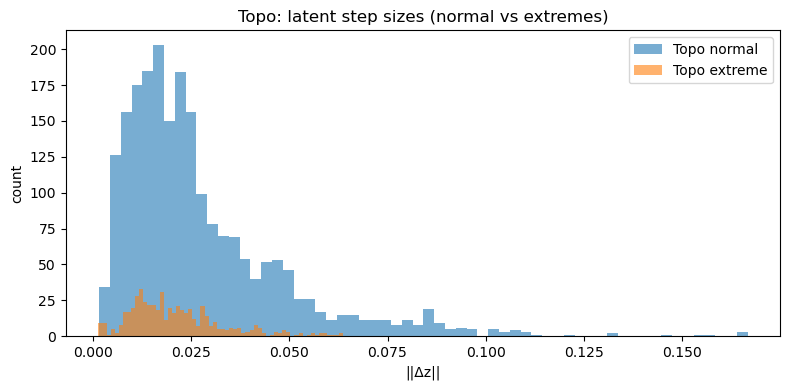

Baseline mean ||Δz|| normal: 0.03998518 extreme: 0.031005379
Topo mean ||Δz|| normal: 0.027468156 extreme: 0.021118192
Ratio extreme/normal baseline: 0.77542174
Ratio extreme/normal topo: 0.7688245


In [59]:
import numpy as np
import matplotlib.pyplot as plt

# use one scalar per sample
y_scalar = y_test.mean(axis=1)   # or y_test[:, 6] for day 7

# latent step sizes aligned to time t (length N-1)
d_b = np.linalg.norm(Zb_te[1:] - Zb_te[:-1], axis=1)
d_a = np.linalg.norm(Za_te[1:] - Za_te[:-1], axis=1)

# choose extremes by storage (top/bottom 10%)
q_low, q_high = np.percentile(y_scalar, [10, 90])
extreme_mask = (y_scalar <= q_low) | (y_scalar >= q_high)
extreme_mask = extreme_mask[1:]   # align with d_* (starts at t=1)

plt.figure(figsize=(8,4))
plt.hist(d_b[~extreme_mask], bins=60, alpha=0.6, label="Baseline normal")
plt.hist(d_b[extreme_mask],  bins=60, alpha=0.6, label="Baseline extreme")
plt.title("Baseline: latent step sizes (normal vs extremes)")
plt.xlabel("||Δz||")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.hist(d_a[~extreme_mask], bins=60, alpha=0.6, label="Topo normal")
plt.hist(d_a[extreme_mask],  bins=60, alpha=0.6, label="Topo extreme")
plt.title("Topo: latent step sizes (normal vs extremes)")
plt.xlabel("||Δz||")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

print("Baseline mean ||Δz|| normal:", d_b[~extreme_mask].mean(), "extreme:", d_b[extreme_mask].mean())
print("Topo mean ||Δz|| normal:",     d_a[~extreme_mask].mean(), "extreme:", d_a[extreme_mask].mean())
print("Ratio extreme/normal baseline:", d_b[extreme_mask].mean()/d_b[~extreme_mask].mean())
print("Ratio extreme/normal topo:",     d_a[extreme_mask].mean()/d_a[~extreme_mask].mean())

In [69]:
# #~3× smaller latent step size
# he strongest signal here is not the ratio.

# It is the absolute latent step magnitude.

# Baseline mean Δz ≈ 0.061
# Topo mean Δz     ≈ 0.021

# This means:

# Topo latent trajectory ≈ 3x smoother